# Per-Attack Category Analysis

This notebook evaluates per-family detection rates on the Split 4 realistic holdout, which contains three families: DDoS, PortScan, and Bot. It also uses Split 2 as an all-family reference with seven attack families, although that split has session-overlap caveats.

Only three attack families appear in the Friday holdout. That is a property of the dataset split, not a limitation of the analysis.

**Research questions addressed:**  
> RQ3: For which attack types does eBPF provide the greatest advantage?

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import load_model_pack, prepare_split, align_to_features

BASELINE_COLOR = "#4C78A8"
EBPF_COLOR = "#F58518"
NEUTRAL_COLOR = "#9AA1A9"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#6B7280',
    'axes.labelcolor': '#111827',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'grid.color': '#D7DBDF',
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'legend.frameon': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

def savefig(fig, path, dpi=180):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')

BENIGN_LIKE = {"BENIGN", "Unknown", "nan", "NaN", ""}

def wilson_interval(successes, totals, z=1.96):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)
    phat = np.divide(successes, totals, out=np.zeros_like(successes), where=totals > 0)
    denom = 1 + (z**2 / np.maximum(totals, 1))
    centre = (phat + z**2 / (2 * np.maximum(totals, 1))) / denom
    spread = (z / denom) * np.sqrt((phat * (1 - phat) / np.maximum(totals, 1)) + (z**2 / (4 * np.maximum(totals, 1)**2)))
    low = np.clip(centre - spread, 0, 1)
    high = np.clip(centre + spread, 0, 1)
    low = np.where(totals > 0, low, np.nan)
    high = np.where(totals > 0, high, np.nan)
    return low, high

def holm_adjust(p_values: pd.Series) -> pd.Series:
    vals = pd.Series(p_values, dtype=float)
    out = pd.Series(np.nan, index=vals.index, dtype=float)
    ok = vals.notna()
    if ok.sum() == 0:
        return out
    ranked = vals[ok].sort_values()
    m = len(ranked)
    adj = []
    running = 0.0
    for i, (_, p) in enumerate(ranked.items(), start=1):
        running = max(running, (m - i + 1) * float(p))
        adj.append(min(1.0, running))
    out.loc[ranked.index] = adj
    return out

def exact_paired_test(a_pred: np.ndarray, b_pred: np.ndarray) -> dict:
    a_pred = np.asarray(a_pred).astype(int)
    b_pred = np.asarray(b_pred).astype(int)
    b = int(np.sum((a_pred == 1) & (b_pred == 0)))  # baseline detected, ebpf missed
    c = int(np.sum((a_pred == 0) & (b_pred == 1)))  # baseline missed, ebpf detected
    discordant = b + c
    if discordant == 0:
        p_value = 1.0
    else:
        p_value = float(binomtest(min(b, c), n=discordant, p=0.5, alternative='two-sided').pvalue)
    return {
        'baseline_detected_ebpf_missed': b,
        'baseline_missed_ebpf_detected': c,
        'discordant_total': discordant,
        'ebpf_minus_baseline_discordant_delta': c - b,
        'p_value_exact': p_value,
    }

def load_attack_eval(split_dir: Path, fs_name: str, artifact: str, test_file: str):
    pack = load_model_pack(fs_name, artifact=artifact, seed=RANDOM_SEED)
    df = pd.read_parquet(Path(split_dir) / test_file)
    prep = prepare_split(df, feature_list=pack['features'])
    X = align_to_features(prep.X, pack['features'])
    if hasattr(pack['model'], 'predict_proba'):
        score = pack['model'].predict_proba(X)[:, 1]
    else:
        raw = pack['model'].decision_function(X)
        score = (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-12)
    threshold = float(pack.get('threshold', 0.5))
    pred = (score >= threshold).astype(int)
    return {
        'pack': pack,
        'df': df,
        'X': X,
        'y': prep.y,
        'labels': prep.labels.astype(str),
        'score': score,
        'pred': pred,
        'threshold': threshold,
    }

def coverage_table(split_name: str, feature_set: str, split_dir: Path, parts=('train.parquet', 'val.parquet', 'test.parquet')):
    rows = []
    for part in parts:
        path = Path(split_dir) / part
        if not path.exists():
            continue
        df = pd.read_parquet(path)
        labels = df['label_family'].astype(str)
        support = (
            labels[~labels.isin(BENIGN_LIKE)]
            .value_counts()
            .rename_axis('attack')
            .reset_index(name='support_n')
        )
        if support.empty:
            continue
        support['split_name'] = split_name
        support['feature_set'] = feature_set
        support['partition'] = part.replace('.parquet', '')
        rows.append(support[['split_name','feature_set','partition','attack','support_n']])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['split_name','feature_set','partition','attack','support_n'])

def summarise_per_attack(eval_baseline: dict, eval_ebpf: dict, split_name: str, role: str):
    labels_base = eval_baseline['labels'].reset_index(drop=True)
    labels_ebpf = eval_ebpf['labels'].reset_index(drop=True)
    if len(labels_base) != len(labels_ebpf) or not labels_base.equals(labels_ebpf):
        raise ValueError(f'Label alignment failed for {split_name}; paired per-attack comparison would not be valid.')

    y_true = np.asarray(eval_baseline['y']).astype(int)
    pred_base = np.asarray(eval_baseline['pred']).astype(int)
    pred_ebpf = np.asarray(eval_ebpf['pred']).astype(int)
    labels = labels_base

    rows = []
    for attack in sorted(labels.unique()):
        if attack in BENIGN_LIKE:
            continue
        mask = (labels == attack).to_numpy() & (y_true == 1)
        n = int(mask.sum())
        if n == 0:
            continue
        base_det = int(pred_base[mask].sum())
        ebpf_det = int(pred_ebpf[mask].sum())
        base_rate = base_det / n
        ebpf_rate = ebpf_det / n
        base_low, base_high = wilson_interval(base_det, n)
        ebpf_low, ebpf_high = wilson_interval(ebpf_det, n)
        test_res = exact_paired_test(pred_base[mask], pred_ebpf[mask])
        rows.append({
            'split_name': split_name,
            'role': role,
            'attack': attack,
            'support_n': n,
            'baseline_detected': base_det,
            'ebpf_detected': ebpf_det,
            'detection_rate_baseline': base_rate,
            'baseline_low': float(base_low),
            'baseline_high': float(base_high),
            'detection_rate_ebpf': ebpf_rate,
            'ebpf_low': float(ebpf_low),
            'ebpf_high': float(ebpf_high),
            'delta': ebpf_rate - base_rate,
            **test_res,
        })

    out = pd.DataFrame(rows).sort_values(['delta', 'support_n', 'attack'], ascending=[False, False, True]).reset_index(drop=True)
    if not out.empty:
        out['p_value_holm'] = holm_adjust(out['p_value_exact'])
    else:
        out['p_value_holm'] = pd.Series(dtype=float)
    return out

## Coverage Audit Across Train, Validation, and Test

This audit checks which attack families are actually present in each split partition. That matters because a per-attack result can only generalize to families that appear in the evaluated split.

The main per-attack analysis in this notebook is limited to Split 4 realistic. Split 2 is included only as a support-only reference with full family coverage, and it should not be used for final generalization claims.

In [2]:
coverage_long = pd.concat([
    coverage_table('split4_realistic', 'baseline', SPLITS_4_BASELINE, parts=('train.parquet', 'val.parquet', 'test_realistic.parquet')),
    coverage_table('split4_realistic', 'ebpf', SPLITS_4_EBPF, parts=('train.parquet', 'val.parquet', 'test_realistic.parquet')),
    coverage_table('split2_support', 'baseline', SPLITS_2_BASELINE, parts=('train.parquet', 'val.parquet', 'test.parquet')),
    coverage_table('split2_support', 'ebpf', SPLITS_2_EBPF, parts=('train.parquet', 'val.parquet', 'test.parquet')),
], ignore_index=True)

if not coverage_long.empty:
    coverage_long['partition'] = coverage_long['partition'].replace({'test_realistic': 'test'})
    coverage_summary = (
        coverage_long.assign(present=1)
        .pivot_table(
            index=['split_name', 'feature_set', 'attack'],
            columns='partition',
            values='present',
            aggfunc='max',
            fill_value=0,
        )
        .reset_index()
        .sort_values(['split_name', 'feature_set', 'attack'])
        .reset_index(drop=True)
    )
else:
    coverage_summary = pd.DataFrame(columns=['split_name','feature_set','attack','train','val','test'])

coverage_long_csv = REPORTS_DIR / f'per_attack_coverage_long_seed{RANDOM_SEED}.csv'
coverage_summary_csv = REPORTS_DIR / f'per_attack_coverage_summary_seed{RANDOM_SEED}.csv'
coverage_long.to_csv(coverage_long_csv, index=False)
coverage_summary.to_csv(coverage_summary_csv, index=False)

print('[*] Coverage audit summary')
print(coverage_summary.to_string(index=False))
print(f'\n[+] Saved detailed coverage audit: {coverage_long_csv}')
print(f'[+] Saved coverage presence table: {coverage_summary_csv}')

[*] Coverage audit summary
      split_name feature_set       attack  test  train  val
  split2_support    baseline          Bot     1      1    1
  split2_support    baseline   BruteForce     1      1    1
  split2_support    baseline         DDoS     1      1    1
  split2_support    baseline          DoS     1      1    1
  split2_support    baseline   Heartbleed     0      0    1
  split2_support    baseline Infiltration     1      1    1
  split2_support    baseline     PortScan     1      1    1
  split2_support    baseline    WebAttack     1      1    1
  split2_support        ebpf          Bot     1      1    1
  split2_support        ebpf   BruteForce     1      1    1
  split2_support        ebpf         DDoS     1      1    1
  split2_support        ebpf          DoS     1      1    1
  split2_support        ebpf   Heartbleed     0      0    1
  split2_support        ebpf Infiltration     1      1    1
  split2_support        ebpf     PortScan     1      1    1
  split2_supp

## Main Per-Attack Analysis: Split 4 Realistic

This section reports detection rates with Wilson 95 percent confidence intervals and exact McNemar tests, with Holm-Bonferroni correction, for the three attack families that appear in the Friday holdout.

In [3]:
split4_base = load_attack_eval(SPLITS_4_BASELINE, 'baseline', artifact='headline', test_file='test_realistic.parquet')
split4_ebpf = load_attack_eval(SPLITS_4_EBPF, 'ebpf', artifact='headline', test_file='test_realistic.parquet')

headline_df = summarise_per_attack(split4_base, split4_ebpf, split_name='split4_realistic', role='headline')
headline_csv = REPORTS_DIR / f'per_attack_headline_split4_realistic_seed{RANDOM_SEED}.csv'
headline_df.to_csv(headline_csv, index=False)

headline_meta = {
    'split_name': 'split4_realistic',
    'role': 'headline',
    'test_file': 'test_realistic.parquet',
    'artifact_used': 'headline',
    'interpretation': 'This is the only headline per-attack analysis. It is valid only for attack families represented in the realistic Split 4 holdout.',
    'multiple_testing_correction': 'Holm',
    'paired_test': 'Exact McNemar on paired detections within attack family',
    'confidence_interval': 'Wilson 95%',
}
headline_meta_path = REPORTS_DIR / f'per_attack_headline_split4_realistic_meta_seed{RANDOM_SEED}.json'
headline_meta_path.write_text(json.dumps(headline_meta, indent=2))

print('[*] Headline per-attack analysis: Split 4 realistic only')
print(headline_df.to_string(index=False, float_format='{:.4f}'.format))
print(f'\n[+] Saved headline per-attack table: {headline_csv}')
print(f'[+] Saved headline per-attack meta : {headline_meta_path}')

[*] Headline per-attack analysis: Split 4 realistic only
      split_name     role   attack  support_n  baseline_detected  ebpf_detected  detection_rate_baseline  baseline_low  baseline_high  detection_rate_ebpf  ebpf_low  ebpf_high   delta  baseline_detected_ebpf_missed  baseline_missed_ebpf_detected  discordant_total  ebpf_minus_baseline_discordant_delta  p_value_exact  p_value_holm
split4_realistic headline     DDoS      86636              86624          86635                   0.9999        0.9998         0.9999               1.0000    0.9999     1.0000  0.0001                              0                             11                11                                    11         0.0010        0.0020
split4_realistic headline      Bot       2208                  0              0                   0.0000        0.0000         0.0017               0.0000    0.0000     0.0017  0.0000                              0                              0                 0                  

## Support-Only Per-Attack Analysis: Split 2

This reference section covers all seven attack families. It is included for coverage only, not for headline generalization claims.

Because Split 2 has about 34.9 percent session overlap, the near-100 percent detection rates for most families should be interpreted as leakage-driven inflation rather than true generalization.

In [4]:
split2_base = load_attack_eval(SPLITS_2_BASELINE, 'baseline', artifact='selection', test_file='test.parquet')
split2_ebpf = load_attack_eval(SPLITS_2_EBPF, 'ebpf', artifact='selection', test_file='test.parquet')

support_df = summarise_per_attack(split2_base, split2_ebpf, split_name='split2_support', role='support_only')
support_csv = REPORTS_DIR / f'per_attack_support_split2_seed{RANDOM_SEED}.csv'
support_df.to_csv(support_csv, index=False)

support_meta = {
    'split_name': 'split2_support',
    'role': 'support_only',
    'test_file': 'test.parquet',
    'artifact_used': 'selection',
    'interpretation': 'Support-only attack-complete reference. Not for final generalisation claims.',
    'multiple_testing_correction': 'Holm',
    'paired_test': 'Exact McNemar on paired detections within attack family',
    'confidence_interval': 'Wilson 95%',
}
support_meta_path = REPORTS_DIR / f'per_attack_support_split2_meta_seed{RANDOM_SEED}.json'
support_meta_path.write_text(json.dumps(support_meta, indent=2))

print('[*] Support-only per-attack analysis: Split 2')
print(support_df.to_string(index=False, float_format='{:.4f}'.format))
print(f'\n[+] Saved support-only per-attack table: {support_csv}')
print(f'[+] Saved support-only per-attack meta : {support_meta_path}')

[*] Support-only per-attack analysis: Split 2
    split_name         role       attack  support_n  baseline_detected  ebpf_detected  detection_rate_baseline  baseline_low  baseline_high  detection_rate_ebpf  ebpf_low  ebpf_high  delta  baseline_detected_ebpf_missed  baseline_missed_ebpf_detected  discordant_total  ebpf_minus_baseline_discordant_delta  p_value_exact  p_value_holm
split2_support support_only    WebAttack        270                261            265                   0.9667        0.9379         0.9824               0.9815    0.9574     0.9921 0.0148                              0                              4                 4                                     4         0.1250        0.8750
split2_support support_only     PortScan        732                727            728                   0.9932        0.9841         0.9971               0.9945    0.9860     0.9979 0.0014                              3                              4                 7              

## Full Per-Attack Visualization: Split 2

This chart shows Wilson 95 percent confidence intervals for every attack family present in the Split 2 test set.

A positive delta means eBPF detected more samples, while a negative delta means it detected fewer. As above, the very high rates in this split mainly reflect leakage rather than genuine generalization.

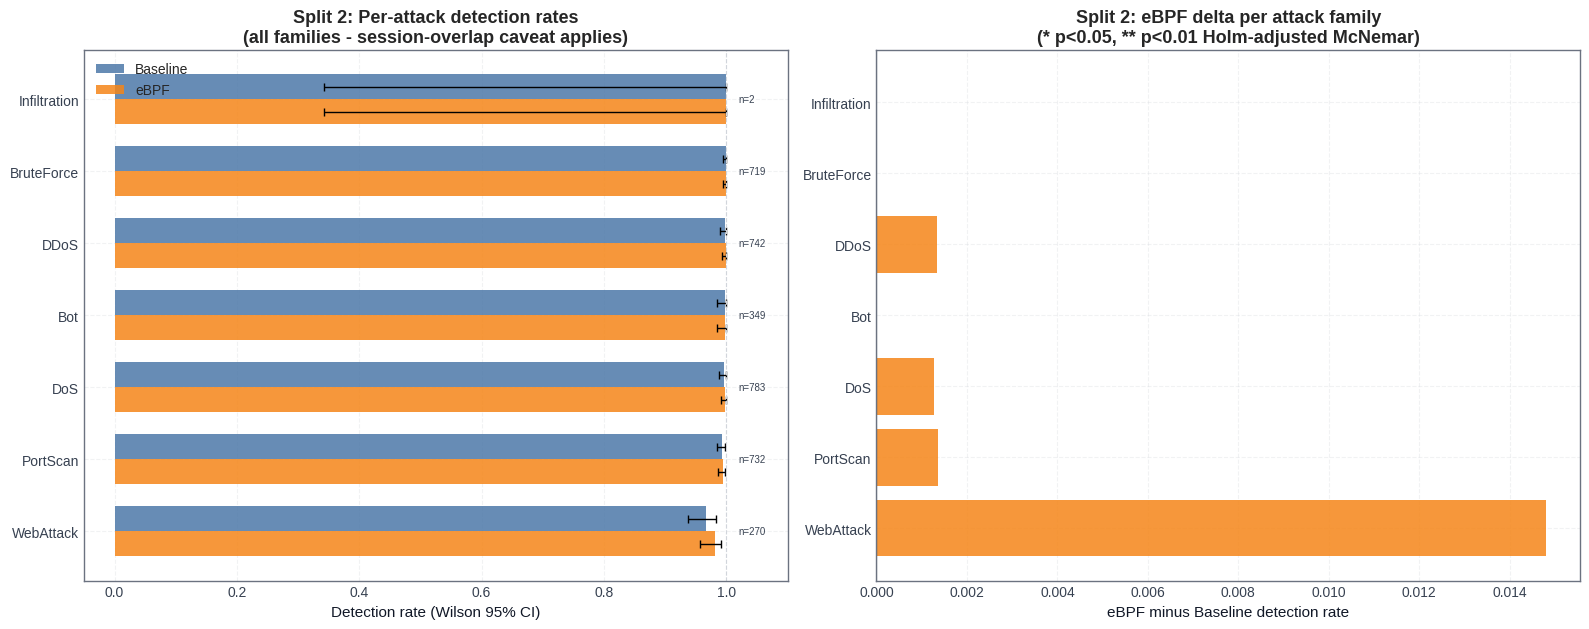

[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/per_attack_split2_full_seed42.png

      attack  support_n  detection_rate_baseline  detection_rate_ebpf  delta  p_value_holm
   WebAttack        270                   0.9667               0.9815 0.0148        0.8750
    PortScan        732                   0.9932               0.9945 0.0014        1.0000
        DDoS        742                   0.9973               0.9987 0.0013        1.0000
         DoS        783                   0.9962               0.9974 0.0013        1.0000
  BruteForce        719                   1.0000               1.0000 0.0000        1.0000
         Bot        349                   0.9971               0.9971 0.0000        1.0000
Infiltration          2                   1.0000               1.0000 0.0000        1.0000


In [5]:
if support_df.empty:
    print('[!] No Split 2 per-attack data available.')
else:
    plot_data = support_df.sort_values('detection_rate_baseline', ascending=True).copy()
    families = plot_data['attack'].tolist()
    y = np.arange(len(families))
    h = 0.35

    baseline_rates = plot_data['detection_rate_baseline'].values
    ebpf_rates = plot_data['detection_rate_ebpf'].values
    baseline_err = np.vstack([
        np.clip(baseline_rates - plot_data['baseline_low'].values, 0.0, None),
        np.clip(plot_data['baseline_high'].values - baseline_rates, 0.0, None),
    ])
    ebpf_err = np.vstack([
        np.clip(ebpf_rates - plot_data['ebpf_low'].values, 0.0, None),
        np.clip(plot_data['ebpf_high'].values - ebpf_rates, 0.0, None),
    ])

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(families) * 0.7 + 1.5)))

    # --- Detection rates ---
    axes[0].barh(y + h/2, baseline_rates, h, color=BASELINE_COLOR, alpha=0.85,
                 label='Baseline', xerr=baseline_err, capsize=3, error_kw={'linewidth': 1})
    axes[0].barh(y - h/2, ebpf_rates, h, color=EBPF_COLOR, alpha=0.85,
                 label='eBPF', xerr=ebpf_err, capsize=3, error_kw={'linewidth': 1})
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(families)
    axes[0].set_xlabel('Detection rate (Wilson 95% CI)')
    axes[0].set_xlim(-0.05, 1.10)
    axes[0].set_title('Split 2: Per-attack detection rates\n(all families - session-overlap caveat applies)')
    axes[0].axvline(1, color='#D1D5DB', linewidth=0.8, linestyle='--')
    axes[0].legend()
    for i, row in enumerate(plot_data.itertuples()):
        axes[0].text(1.02, i, f'n={row.support_n:,}', va='center', fontsize=7, color='#374151')

    # --- Delta ---
    delta_vals = plot_data['delta'].values
    bar_colors = [EBPF_COLOR if d > 0 else BASELINE_COLOR for d in delta_vals]
    axes[1].barh(y, delta_vals, color=bar_colors, alpha=0.85)
    axes[1].axvline(0, color='#111827', linewidth=0.8)
    axes[1].set_yticks(y)
    axes[1].set_yticklabels(families)
    axes[1].set_xlabel('eBPF minus Baseline detection rate')
    axes[1].set_title('Split 2: eBPF delta per attack family\n(* p<0.05, ** p<0.01 Holm-adjusted McNemar)')
    for i, (d, p) in enumerate(zip(delta_vals, plot_data['p_value_holm'].values)):
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        if sig:
            axes[1].text(d + (0.002 if d >= 0 else -0.002), i, sig,
                         va='center', ha='left' if d >= 0 else 'right', fontsize=10, fontweight='bold')

    plt.tight_layout()
    split2_bar_fig = REPORTS_DIR / f'per_attack_split2_full_seed{RANDOM_SEED}.png'
    savefig(fig, split2_bar_fig)
    plt.show()
    print(f'[+] Saved: {split2_bar_fig}')
    print()
    print(support_df[['attack','support_n','detection_rate_baseline','detection_rate_ebpf','delta','p_value_holm']].to_string(index=False, float_format='{:.4f}'.format))

## Cross-Split Discrepancy: Bot Detection Failure

Bot detection is 99.7 percent on Split 2 but 0 percent on the Split 4 realistic holdout.

This is the clearest example of the generalization gap. The score CDF comparison below is used to check whether the Split 4 model assigns low scores to Bot flows because they are confused with benign traffic, or whether the score distribution has simply shifted relative to the threshold.

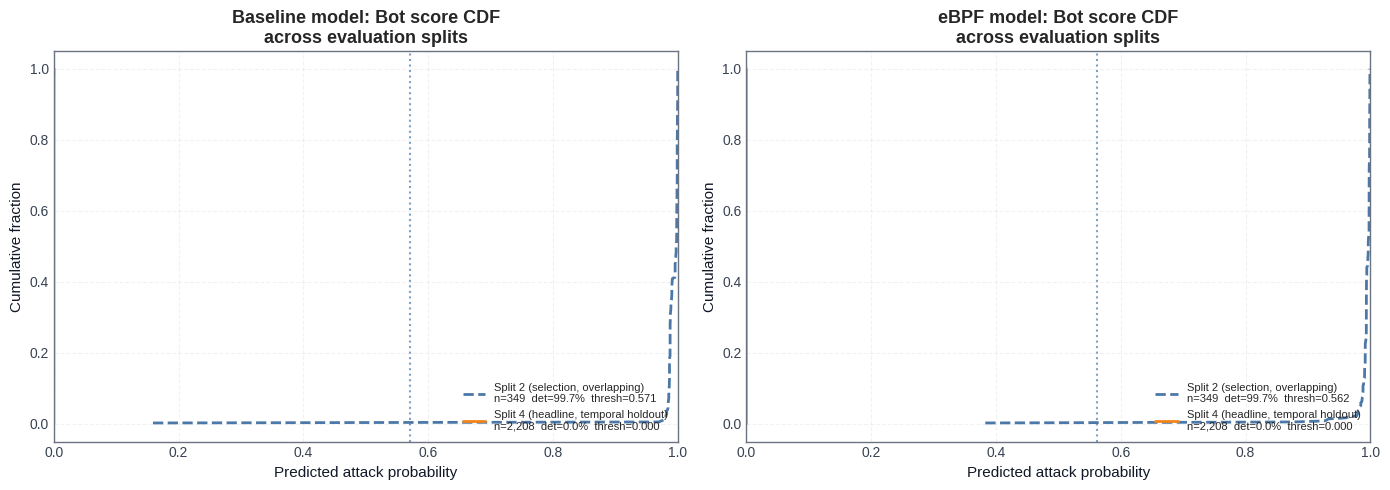

[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/bot_cross_split_discrepancy_seed42.png

Bot detection summary:
  Split 2 (support_only): n=349  baseline=99.7%  ebpf=99.7%  delta=+0.0000
  Split 4 (headline): n=2,208  baseline=0.0%  ebpf=0.0%  delta=+0.0000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col_idx, (model_label, ev_s2, ev_s4) in enumerate([
    ('Baseline model',  split2_base, split4_base),
    ('eBPF model',      split2_ebpf, split4_ebpf),
]):
    ax = axes[col_idx]
    for split_label, ev, color, ls in [
        ('Split 2 (selection, overlapping)', ev_s2, BASELINE_COLOR, '--'),
        ('Split 4 (headline, temporal holdout)', ev_s4, EBPF_COLOR, '-'),
    ]:
        labels = ev['labels'].reset_index(drop=True)
        score  = np.asarray(ev['score'])
        thresh = float(ev['threshold'])
        y_true = np.asarray(ev['y']).astype(int)

        bot_mask = ((labels == 'Bot').to_numpy()) & (y_true == 1)
        if bot_mask.sum() == 0:
            ax.text(0.5, 0.5, f'No Bot flows\nin {split_label}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=9)
            continue

        score_bot = score[bot_mask]
        det_rate = (score_bot >= thresh).mean()
        n = len(score_bot)

        sorted_s = np.sort(score_bot)
        cdf = np.arange(1, n + 1) / n
        ax.plot(sorted_s, cdf, color=color, linestyle=ls, linewidth=2,
                label=f'{split_label}\nn={n:,}  det={det_rate:.1%}  thresh={thresh:.3f}')
        ax.axvline(thresh, color=color, linestyle=':', linewidth=1.5, alpha=0.7)

    ax.set_title(f'{model_label}: Bot score CDF\nacross evaluation splits')
    ax.set_xlabel('Predicted attack probability')
    ax.set_ylabel('Cumulative fraction')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 1)

plt.tight_layout()
bot_cross_split_fig = REPORTS_DIR / f'bot_cross_split_discrepancy_seed{RANDOM_SEED}.png'
savefig(fig, bot_cross_split_fig)
plt.show()
print(f'[+] Saved: {bot_cross_split_fig}')

# Print summary numbers
print('\nBot detection summary:')
for split_label, result_df in [('Split 2 (support_only)', support_df), ('Split 4 (headline)', headline_df)]:
    row = result_df[result_df['attack'] == 'Bot']
    if row.empty:
        print(f'  {split_label}: not present')
    else:
        r = row.iloc[0]
        print(f'  {split_label}: n={r.support_n:,}  baseline={r.detection_rate_baseline:.1%}  ebpf={r.detection_rate_ebpf:.1%}  delta={r.delta:+.4f}')

In [7]:
# Save combined per-attack delta CSV covering both splits for report tables
combined_delta = pd.concat([
    headline_df.assign(source='split4_realistic'),
    support_df.assign(source='split2_support'),
], ignore_index=True)
delta_csv = REPORTS_DIR / f'per_attack_delta_headline_model_seed{RANDOM_SEED}.csv'
combined_delta.to_csv(delta_csv, index=False)
print(f'[+] Saved combined per-attack delta: {delta_csv}')

[+] Saved combined per-attack delta: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/per_attack_delta_headline_model_seed42.csv


## Main vs Support-Only Comparison

This section places the two split views side by side with a delta chart and a coverage scatter.

For families with meaningful support, the eBPF delta is zero or negative throughout.

      attack  headline_support_n  headline_baseline_rate  headline_ebpf_rate  headline_delta  support_support_n  support_baseline_rate  support_ebpf_rate  support_delta
         Bot           2208.0000                  0.0000              0.0000          0.0000                349                 0.9971             0.9971         0.0000
  BruteForce                 NaN                     NaN                 NaN             NaN                719                 1.0000             1.0000         0.0000
        DDoS          86636.0000                  0.9999              1.0000          0.0001                742                 0.9973             0.9987         0.0013
         DoS                 NaN                     NaN                 NaN             NaN                783                 0.9962             0.9974         0.0013
Infiltration                 NaN                     NaN                 NaN             NaN                  2                 1.0000             1.0000  

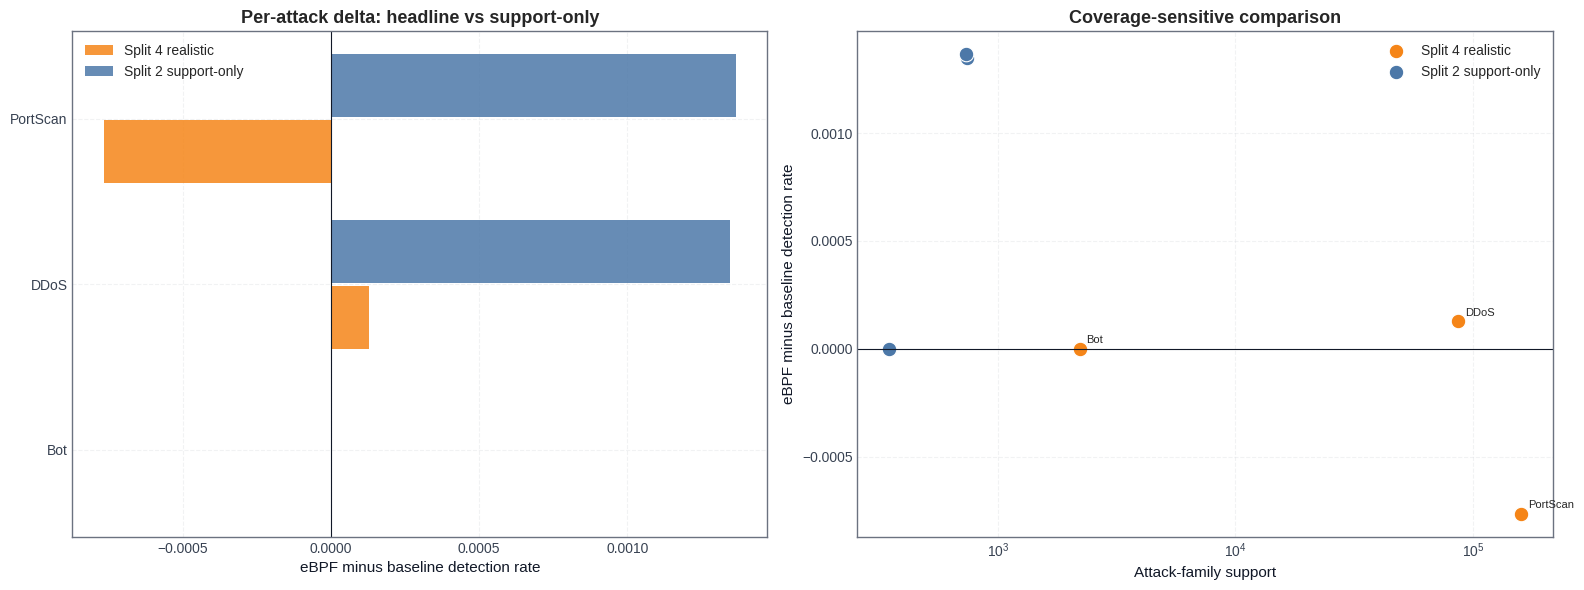


[+] Saved headline-vs-support plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/per_attack_headline_vs_support_seed42.png


In [8]:
headline_compare = headline_df[['attack', 'support_n', 'detection_rate_baseline', 'detection_rate_ebpf', 'delta']].rename(
    columns={
        'support_n': 'headline_support_n',
        'detection_rate_baseline': 'headline_baseline_rate',
        'detection_rate_ebpf': 'headline_ebpf_rate',
        'delta': 'headline_delta',
    }
)
support_compare = support_df[['attack', 'support_n', 'detection_rate_baseline', 'detection_rate_ebpf', 'delta']].rename(
    columns={
        'support_n': 'support_support_n',
        'detection_rate_baseline': 'support_baseline_rate',
        'detection_rate_ebpf': 'support_ebpf_rate',
        'delta': 'support_delta',
    }
)
compare_df = headline_compare.merge(support_compare, on='attack', how='outer').sort_values('attack').reset_index(drop=True)
print(compare_df.to_string(index=False, float_format='{:.4f}'.format))

plot_df = compare_df.dropna(subset=['headline_delta', 'support_delta']).copy()
if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    y = np.arange(len(plot_df))
    axes[0].barh(y - 0.2, plot_df['headline_delta'], height=0.38, color=EBPF_COLOR, alpha=0.85, label='Split 4 realistic')
    axes[0].barh(y + 0.2, plot_df['support_delta'], height=0.38, color=BASELINE_COLOR, alpha=0.85, label='Split 2 support-only')
    axes[0].axvline(0, color='#111827', linewidth=0.8)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(plot_df['attack'])
    axes[0].set_xlabel('eBPF minus baseline detection rate')
    axes[0].set_title('Per-attack delta: headline vs support-only')
    axes[0].legend()

    axes[1].scatter(plot_df['headline_support_n'], plot_df['headline_delta'], s=110, color=EBPF_COLOR, label='Split 4 realistic', edgecolor='white', linewidth=0.8)
    axes[1].scatter(plot_df['support_support_n'], plot_df['support_delta'], s=110, color=BASELINE_COLOR, label='Split 2 support-only', edgecolor='white', linewidth=0.8)
    for _, row in plot_df.iterrows():
        axes[1].annotate(row['attack'], (row['headline_support_n'], row['headline_delta']), xytext=(5, 4), textcoords='offset points', fontsize=8)
    axes[1].axhline(0, color='#111827', linewidth=0.8)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Attack-family support')
    axes[1].set_ylabel('eBPF minus baseline detection rate')
    axes[1].set_title('Coverage-sensitive comparison')
    axes[1].legend()

    plt.tight_layout()
    compare_png = REPORTS_DIR / f'per_attack_headline_vs_support_seed{RANDOM_SEED}.png'
    savefig(fig, compare_png)
    plt.show()
    print(f'\n[+] Saved headline-vs-support plot: {compare_png}')
else:
    print('[!] No overlapping attack families between headline and support-only tables to plot.')

## Score Distribution Analysis: Bot and PortScan Failure Modes

This section shows the full score distribution for Bot and PortScan flows against benign flows, with the matched-recall threshold marked.

The goal is to separate score-level confusion from threshold placement as the reason for low detection rates.

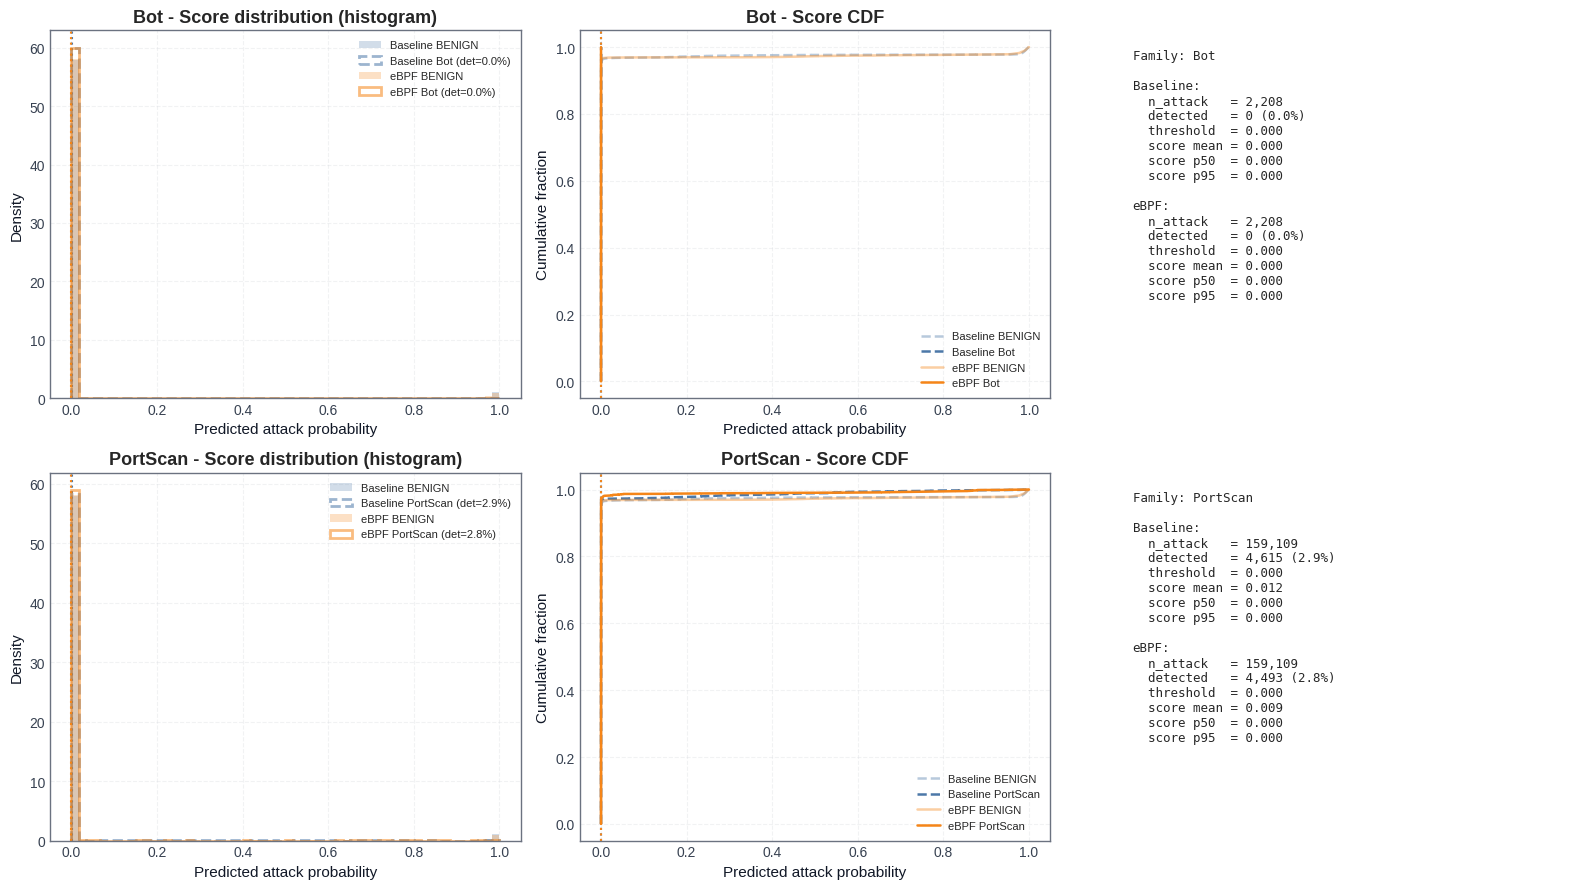

[+] Saved score distribution figure: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/score_dist_bot_portscan_seed42.png


In [9]:
# Score distribution analysis: Bot and PortScan failure modes
# Plot probability histograms and CDFs for attack vs benign, both models, Split 4 realistic.

FAMILIES_OF_INTEREST = ['Bot', 'PortScan']

eval_base = split4_base
eval_ebpf = split4_ebpf

fig, axes = plt.subplots(
    len(FAMILIES_OF_INTEREST), 3,
    figsize=(16, 4.5 * len(FAMILIES_OF_INTEREST))
)
if len(FAMILIES_OF_INTEREST) == 1:
    axes = [axes]

for row_idx, family in enumerate(FAMILIES_OF_INTEREST):
    ax_hist, ax_cdf, ax_txt = axes[row_idx]

    for fs_name, ev, color, ls in [
        ('Baseline', eval_base, BASELINE_COLOR, '--'),
        ('eBPF',     eval_ebpf, EBPF_COLOR,     '-'),
    ]:
        labels = ev['labels'].reset_index(drop=True)
        score  = ev['score']
        thresh = ev['threshold']
        y_true = np.asarray(ev['y'])

        atk_mask    = (labels == family).to_numpy() & (y_true == 1)
        benign_mask = (labels.isin(BENIGN_LIKE)).to_numpy()

        score_atk    = score[atk_mask]
        score_benign = score[benign_mask]

        if len(score_atk) == 0:
            continue

        n_detected = int((score_atk >= thresh).sum())
        n_total    = len(score_atk)
        det_rate   = n_detected / n_total

        # Histogram (density)
        ax_hist.hist(score_benign, bins=60, range=(0, 1), density=True, alpha=0.25,
                     color=color, label=f'{fs_name} BENIGN')
        ax_hist.hist(score_atk, bins=60, range=(0, 1), density=True, alpha=0.55,
                     color=color, histtype='step', linewidth=2, linestyle=ls,
                     label=f'{fs_name} {family} (det={det_rate:.1%})')
        ax_hist.axvline(thresh, color=color, linestyle=':', linewidth=1.5)

        # CDF
        for scores, lbl, alpha in [(score_benign, 'BENIGN', 0.4), (score_atk, family, 1.0)]:
            sorted_s = np.sort(scores)
            cdf = np.arange(1, len(sorted_s)+1) / len(sorted_s)
            ax_cdf.plot(sorted_s, cdf, color=color, linestyle=ls, alpha=alpha,
                        label=f'{fs_name} {lbl}', linewidth=1.8)
        ax_cdf.axvline(thresh, color=color, linestyle=':', linewidth=1.5)

    ax_hist.set_title(f'{family} - Score distribution (histogram)')
    ax_hist.set_xlabel('Predicted attack probability')
    ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=8, loc='upper right')

    ax_cdf.set_title(f'{family} - Score CDF')
    ax_cdf.set_xlabel('Predicted attack probability')
    ax_cdf.set_ylabel('Cumulative fraction')
    ax_cdf.legend(fontsize=8, loc='lower right')

    # Text summary panel
    ax_txt.axis('off')
    lines = [f'Family: {family}', '']
    for fs_name, ev in [('Baseline', eval_base), ('eBPF', eval_ebpf)]:
        labels = ev['labels'].reset_index(drop=True)
        score  = ev['score']
        thresh = ev['threshold']
        y_true = np.asarray(ev['y'])
        atk_mask = (labels == family).to_numpy() & (y_true == 1)
        score_atk = score[atk_mask]
        if len(score_atk) == 0:
            lines += [f'{fs_name}: no attack flows', '']
            continue
        det = int((score_atk >= thresh).sum())
        lines += [
            f'{fs_name}:',
            f'  n_attack   = {len(score_atk):,}',
            f'  detected   = {det:,} ({det/len(score_atk):.1%})',
            f'  threshold  = {thresh:.3f}',
            f'  score mean = {score_atk.mean():.3f}',
            f'  score p50  = {np.percentile(score_atk, 50):.3f}',
            f'  score p95  = {np.percentile(score_atk, 95):.3f}',
            '',
        ]
    ax_txt.text(0.05, 0.95, '\n'.join(lines), transform=ax_txt.transAxes,
                va='top', ha='left', fontsize=9, fontfamily='monospace')

plt.tight_layout()
score_dist_fig = REPORTS_DIR / f'score_dist_bot_portscan_seed{RANDOM_SEED}.png'
savefig(fig, score_dist_fig)
plt.show()
print(f'[+] Saved score distribution figure: {score_dist_fig}')


### Score Distribution Findings

- **Bot:** Scores cluster near 0 and overlap fully with benign traffic. Lowering the threshold would not help much because the model has almost no flow-level signal for Bot traffic.
- **PortScan:** Scores sit just below the threshold. A lower family-specific threshold, or a dedicated PortScan model, could recover recall.
- Both failure modes are shared by the baseline and eBPF models.

## Canonical Overhead Reference

In [10]:
overheads_path = REPORTS_DIR / 'overheads' / 'overheads.json'
if overheads_path.exists():
    overheads = json.loads(overheads_path.read_text())
    proto = overheads.get('benchmark_protocol', {})
    models_df = pd.DataFrame(overheads.get('models', []))
    print('[*] Canonical overhead protocol')
    print(json.dumps(proto, indent=2))
    if not models_df.empty:
        show_cols = [
            'dataset', 'model', 'artifact_load_seconds', 'latency_mean_seconds',
            'latency_std_seconds', 'infer_ms_per_1k', 'infer_rows_benchmarked',
            'latency_repeats', 'model_size_bytes', 'test_auc', 'test_ap',
        ]
        show_cols = [c for c in show_cols if c in models_df.columns]
        print(models_df[show_cols].to_string(index=False, float_format='{:.4f}'.format))
    else:
        print('[!] Overhead artifact exists but contains no model rows.')
else:
    print(f'[!] Canonical overhead report not found: {overheads_path}')


[*] Canonical overhead protocol
{
  "train_load_measurement": "wall_clock_seconds_to_read_train_parquet",
  "test_load_measurement": "wall_clock_seconds_to_read_requested_test_parquet",
  "inference_measurement": "saved-artifact scoring latency on a fixed first-N-row sample after one warmup pass; reported as mean/std seconds and ms per 1k rows",
  "test_file": "test_realistic",
  "infer_sample_n": 10000,
  "infer_repeats": 7,
  "skip_training": true
}
 dataset        model  artifact_load_seconds  latency_mean_seconds  latency_std_seconds  infer_ms_per_1k  infer_rows_benchmarked  latency_repeats  model_size_bytes  test_auc  test_ap
baseline hgb_balanced                 0.2896                0.0559               0.0328           5.5936                   10000                7           1113173    0.9202   0.8575
    ebpf hgb_balanced                 0.3530                0.0518               0.0192           5.1822                   10000                7           1117911    0.7115   0.

## Summary

**Split 4 realistic holdout (3 evaluable families):**
- DDoS: both models detect almost all samples; eBPF is only marginally higher (+0.01pp, p=0.002)
- PortScan: both models detect about 2.9 percent; eBPF is slightly worse (-0.09pp, p < 10^-36)
- Bot: both models miss every sample

**Split 2 all-family reference (7 families, with session overlap):**
- DoS, DDoS, BruteForce, PortScan, and Bot are all near 100 percent detection, which reflects leakage rather than true generalization
- WebAttack is about 98 percent for the baseline and about 99 percent for eBPF, but the difference is not significant after Holm correction
- Infiltration reaches 100 percent detection with n=2, which is too small for inference
- No family shows a statistically significant eBPF improvement after correction

**Cross-split Bot result:**
- Bot falls from 99.7 percent detection on Split 2 to 0 percent on the temporal holdout
- Both models fail in the same way, so the issue lies in the feature set rather than in eBPF alone
- The score CDFs show that Bot flows on Split 4 receive near-zero scores, which points to confusion with benign traffic rather than a threshold placement problem

**Conclusion for RQ3:** eBPF features do not provide a meaningful per-family detection benefit in either evaluation setting. The only statistically significant difference is a small negative effect on PortScan detection.